# 01 - Data Preparation

# Ligue 1 Elo Rating Model (FiveThirtyEight SPI Data)

In this notebook, we build a basic Elo rating model for Ligue 1 using the FiveThirtyEight `spi_matches.csv` dataset.

Steps:
1. Load and preprocess the match data for Ligue 1.
2. Set up an Elo rating system for all teams.
3. Iterate through matches chronologically and update Elo ratings.
4. Store match-level Elo ratings before and after each game for later analysis.


## Setup

In [1]:
import pandas as pd
from pathlib import Path
import numpy as np

DATA_DIR = Path("../data/raw")
df = pd.read_csv(DATA_DIR / "spi_matches.csv")
df.head(), len(df)


(         date  league_id        team1                team2   spi1   spi2  \
 0  2016-08-12       1843       bastia  paris saint-germain  51.16  85.68   
 1  2016-08-12       1843    as monaco             guingamp  68.85  56.48   
 2  2016-08-13       2411    hull city       leicester city  53.57  66.81   
 3  2016-08-13       2411      burnley         swansea city  58.98  59.74   
 4  2016-08-13       2411  southampton              watford  69.49  59.33   
 
     prob1   prob2  probtie  proj_score1  proj_score2  score1  score2   xg1  \
 0  0.0463  0.8380   0.1157         0.91         2.36     0.0     1.0  0.97   
 1  0.5714  0.1669   0.2617         1.82         0.86     2.0     2.0  2.45   
 2  0.3459  0.3621   0.2921         1.16         1.24     2.0     1.0  0.85   
 3  0.4482  0.2663   0.2854         1.37         1.05     0.0     1.0  1.24   
 4  0.5759  0.1874   0.2367         1.91         1.05     1.0     1.0  1.05   
 
     xg2  nsxg1  nsxg2  adj_score1  adj_score2  
 0  0.63   

In [2]:

df = df[["date", "league_id", "team1", "team2", "score1", "score2"]].copy()
df["date"] = pd.to_datetime(df["date"])

df.rename(columns={
    "team1": "HomeTeam",
    "team2": "AwayTeam",
    "score1": "FTHG",
    "score2": "FTAG"
}, inplace=True)

df = df.dropna(subset=["FTHG", "FTAG"])
df = df.sort_values("date")

df.head()


,date,league_id,HomeTeam,AwayTeam,FTHG,FTAG
0,2016-08-12,1843,bastia,paris saint-germain,0.0,1.0
1,2016-08-12,1843,as monaco,guingamp,2.0,2.0
2,2016-08-13,2411,hull city,leicester city,2.0,1.0
3,2016-08-13,2411,burnley,swansea city,0.0,1.0
4,2016-08-13,2411,southampton,watford,1.0,1.0


## Load data

In [3]:
# Convert date column to proper datetime format
df["date"] = pd.to_datetime(df["date"], errors="coerce")

# Ligue 1 league_id according to FiveThirtyEight's documentation
LIGUE1_LEAGUE_ID = 1843

# Filter only Ligue 1 matches
ligue1_df = df[df["league_id"] == LIGUE1_LEAGUE_ID].copy()

# Rename columns to match the Elo modeling pipeline
ligue1_df.rename(columns={
    "team1": "HomeTeam",
    "team2": "AwayTeam",
    "score1": "FTHG",   # Full Time Home Goals
    "score2": "FTAG"    # Full Time Away Goals
}, inplace=True)

# Drop matches without valid scores
ligue1_df = ligue1_df.dropna(subset=["FTHG", "FTAG"])

# Sort matches chronologically to ensure correct Elo updating
ligue1_df = ligue1_df.sort_values("date").reset_index(drop=True)

# Display sample
ligue1_df.head()


,date,league_id,HomeTeam,AwayTeam,FTHG,FTAG
0,2016-08-12,1843,bastia,paris saint-germain,0.0,1.0
1,2016-08-12,1843,as monaco,guingamp,2.0,2.0
2,2016-08-13,1843,bordeaux,st etienne,3.0,2.0
3,2016-08-13,1843,metz,lille,3.0,2.0
4,2016-08-13,1843,caen,lorient,3.0,2.0


## Modelling

### 2. Initialize Elo ratings for all teams

In this step, we create a working copy of the preprocessed Ligue 1 data and
set up the containers needed for the Elo model:

- `matches`: a clean match-level dataframe for Ligue 1.  
- `START_ELO`: the initial rating assigned to any team that appears for the first time.  
- `team_elos`: a dictionary that stores the current Elo rating for each team.

This state will be updated match by match as we process the season chronologically.


In [4]:
# Copy the preprocessed Ligue 1 dataframe
matches = ligue1_df.copy()
# Add season column based on calendar year
matches["season"] = matches["date"].dt.year

# Initialize Elo dictionary with a default starting rating
START_ELO = 1500

# Home advantage in Elo points (can be tuned later)
HOME_ADVANTAGE = 70.0

# Dictionary that stores current Elo ratings for each team
team_elos = {}


### 3. Helper function: get the current Elo rating for a team

We now define a small helper function, `get_elo(team)`, which:

- Returns the current Elo rating of a given team if it already exists.
- If the team has not appeared before, it initializes the team with the default `START_ELO`.

This keeps the Elo dictionary logic in one place and makes the main loop cleaner.


In [5]:
def get_elo(team: str) -> float:
    """
    Return the current Elo rating of a team.
    If the team is not yet in the dictionary, initialize it with START_ELO.
    """
    if team not in team_elos:
        team_elos[team] = START_ELO
    return team_elos[team]


### 4. Define the expected score function

Elo ratings can be converted into expected scores using the standard logistic formula.
For two teams A and B with ratings `elo_a` and `elo_b`:

\[
E_A = \frac{1}{1 + 10^{(elo_b - elo_a)/400}}
\]

This gives the probability that team A gets a better result than team B
(win = 1, draw = 0.5, loss = 0).


In [6]:
import numpy as np

def expected_score(elo_a: float, elo_b: float) -> float:
    """
    Calculate the expected score for team A against team B using the Elo formula.
    """
    return 1 / (1 + 10 ** ((elo_b - elo_a) / 400))


### 5. Define the Elo update function

The `update_elo` function does the following:

- Fetches the current ratings for home and away teams.
- Computes the expected scores using their Elo ratings.
- Computes the actual scores based on the match result:
  - Home win → (1, 0)
  - Away win → (0, 1)
  - Draw     → (0.5, 0.5)
- Updates both ratings using the standard Elo update rule:

\[
\text{new\_elo} = \text{old\_elo} + K \cdot (\text{actual} - \text{expected})
\]

We will start with a constant `K` value and may tune it later.


In [7]:
# Reset Elo at the start of each season
matches["season"] = matches["date"].dt.year

# Group matches by season
season_groups = matches.groupby("season")

In [8]:
def update_elo(
    home: str,
    away: str,
    home_goals: float,
    away_goals: float,
    base_k: float = 20.0
):
    """
    Update Elo ratings for both teams based on the match result.
    Includes home advantage and a simple dynamic K-factor.
    Returns updated (home_elo, away_elo).
    """

    # Current ratings
    home_elo = get_elo(home)
    away_elo = get_elo(away)

    # Apply home advantage only for calculating expectations
    home_elo_with_adv = home_elo + HOME_ADVANTAGE

    # Expected scores
    exp_home = expected_score(home_elo_with_adv, away_elo)
    exp_away = 1 - exp_home

    # Actual outcomes
    if home_goals > away_goals:
        score_home, score_away = 1.0, 0.0
    elif home_goals < away_goals:
        score_home, score_away = 0.0, 1.0
    else:
        score_home, score_away = 0.5, 0.5

    # Dynamic K-factor: increase when goal difference is larger
    goal_diff = abs(home_goals - away_goals)
    k_factor = base_k + 5.0 * goal_diff

    # Elo updates (we update the "raw" ratings, not including the advantage)
    new_home_elo = home_elo + k_factor * (score_home - exp_home)
    new_away_elo = away_elo + k_factor * (score_away - exp_away)

    # Persist updated ratings
    team_elos[home] = new_home_elo
    team_elos[away] = new_away_elo

    return new_home_elo, new_away_elo


### 6. Create a structure to store Elo progression over time

For analysis and visualization, we need to keep track of how each team's
Elo rating changes throughout the season.

We will create an empty list called `elo_history`.  
Each match will generate one row containing:

- Match date  
- Teams  
- Goals scored  
- Elo values before the match  
- Elo values after the match  

At the end, this list will be converted into a DataFrame (`elo_df`).


In [9]:
# A list to store Elo evolution for every match
elo_history = []


### 7. Process matches chronologically and update Elo ratings

Now we iterate over each match in the dataset (already sorted by date), and:

1. Read home/away teams and goals.
2. Retrieve their Elo ratings *before* the match.
3. Apply `update_elo()` to compute their *new* ratings.
4. Store all relevant information in a structured dictionary.
5. Append the dictionary into `elo_history`.

This loop produces the complete Elo timeline for Ligue 1.


In [10]:
# A list to store Elo evolution for every match
elo_history = []
team_elos = {}

for season, season_matches in season_groups:
    # Reset Elo at the start of each season
    team_elos = {}

    # Ensure matches in this season are sorted by date
    season_matches = season_matches.sort_values("date")

    for _, row in season_matches.iterrows():
        home = row["HomeTeam"]
        away = row["AwayTeam"]
        hg = float(row["FTHG"])
        ag = float(row["FTAG"])
        date = row["date"]

        # Elo before the match (raw ratings, without home advantage)
        home_before = get_elo(home)
        away_before = get_elo(away)

        # Update ratings (update_elo already writes into team_elos)
        home_after, away_after = update_elo(home, away, hg, ag)

        # Store history
        elo_history.append({
            "season": season,
            "date": date,
            "HomeTeam": home,
            "AwayTeam": away,
            "FTHG": hg,
            "FTAG": ag,
            "home_elo_before": home_before,
            "away_elo_before": away_before,
            "home_elo_after": home_after,
            "away_elo_after": away_after
        })


### 8. Convert Elo history into a DataFrame

After iterating through all matches, we convert the `elo_history` list into
a DataFrame called `elo_df`.

This DataFrame allows us to:

- Visualize Elo changes over time  
- Compare team strengths  
- Validate match predictions  
- Conduct further evaluation and simulations

This is the core output of the Elo model.


In [11]:
elo_df = pd.DataFrame(elo_history)
elo_df.head()


,season,date,HomeTeam,AwayTeam,FTHG,FTAG,home_elo_before,away_elo_before,home_elo_after,away_elo_after
0,2016,2016-08-12,bastia,paris saint-germain,0.0,1.0,1500.0,1500.0,1485.015080,1514.984920
1,2016,2016-08-12,as monaco,guingamp,2.0,2.0,1500.0,1500.0,1498.012064,1501.987936
2,2016,2016-08-13,bordeaux,st etienne,3.0,2.0,1500.0,1500.0,1510.015080,1489.984920
3,2016,2016-08-13,metz,lille,3.0,2.0,1500.0,1500.0,1510.015080,1489.984920
4,2016,2016-08-13,caen,lorient,3.0,2.0,1500.0,1500.0,1510.015080,1489.984920


## Evaluation – Predicting match outcomes from Elo

We now convert Elo ratings into three-way probabilities (home win, draw, away win)
and use them to generate discrete predictions (H/D/A).


In [12]:
# Base draw probability (can be tuned later)
# DRAW_BASE = 0.25 # 0.15 + 0.15 * np.exp(-abs(home_elo_with_adv - away_elo_before) / 300)

def elo_to_probabilities(home_elo_before: float, away_elo_before: float):
    """
    Convert Elo ratings into (p_home, p_draw, p_away).

    We:
    - apply home advantage to the home team's rating,
    - compute the expected score using the Elo formula,
    - keep a fixed base draw probability,
    - distribute the remaining probability mass between home and away.
    """
    # Apply home advantage for the probability calculation
    home_elo_with_adv = home_elo_before + HOME_ADVANTAGE

    # Expected score for home team (between 0 and 1)
    exp_home = expected_score(home_elo_with_adv, away_elo_before)

    # Start with a fixed draw probability
    p_draw = 0.15 + 0.15 * np.exp(-abs(home_elo_with_adv - away_elo_before) / 300)

    # Use the expected score to derive home/away probabilities
    # This is a simple, interpretable transformation, not a perfect model.
    p_home = exp_home - 0.5 * p_draw
    p_away = 1.0 - p_home - p_draw

    # Clamp to [0, 1] and re-normalize to avoid numerical issues
    p_home = max(0.0, min(1.0, p_home))
    p_away = max(0.0, min(1.0, p_away))

    total = p_home + p_draw + p_away
    p_home /= total
    p_draw /= total
    p_away /= total

    return p_home, p_draw, p_away


In [13]:
def predict_outcome_from_elo(home_elo_before: float, away_elo_before: float) -> str:
    """
    Turn Elo ratings into a discrete outcome prediction: 'H', 'D', or 'A'.
    """
    p_home, p_draw, p_away = elo_to_probabilities(home_elo_before, away_elo_before)
    probs = np.array([p_home, p_draw, p_away])
    labels = np.array(["H", "D", "A"])
    return labels[probs.argmax()]

# Actual results from goals
elo_df["actual"] = np.where(
    elo_df["FTHG"] > elo_df["FTAG"], "H",
    np.where(elo_df["FTHG"] < elo_df["FTAG"], "A", "D")
)

# Predictions from Elo
elo_df["pred"] = elo_df.apply(
    lambda row: predict_outcome_from_elo(row["home_elo_before"], row["away_elo_before"]),
    axis=1
)

# Accuracy
accuracy = (elo_df["pred"] == elo_df["actual"]).mean()
float(accuracy)


0.5131578947368421

### Final Elo ratings for each team

To understand the outcome of the model, we look at the final Elo rating of every team.
This gives us a snapshot of the team strengths at the end of the dataset.


In [14]:
final_elos = (
    elo_df.groupby("HomeTeam")["home_elo_after"].last()
    .combine_first(
        elo_df.groupby("AwayTeam")["away_elo_after"].last()
    )
)

final_elos.sort_values(ascending=False).head(10)


HomeTeam
paris saint-germain    1632.545586
marseille              1592.073043
lyon                   1585.255807
as monaco              1577.866938
st etienne             1566.301375
stade rennes           1558.484184
bordeaux               1548.268295
nice                   1528.555972
amiens                 1504.819340
montpellier            1500.954208
Name: home_elo_after, dtype: float64

### Elo progression of a specific team

Visualizing the Elo timeline of a single team (e.g., PSG) helps us see
how its strength evolves through wins, losses, and draws.


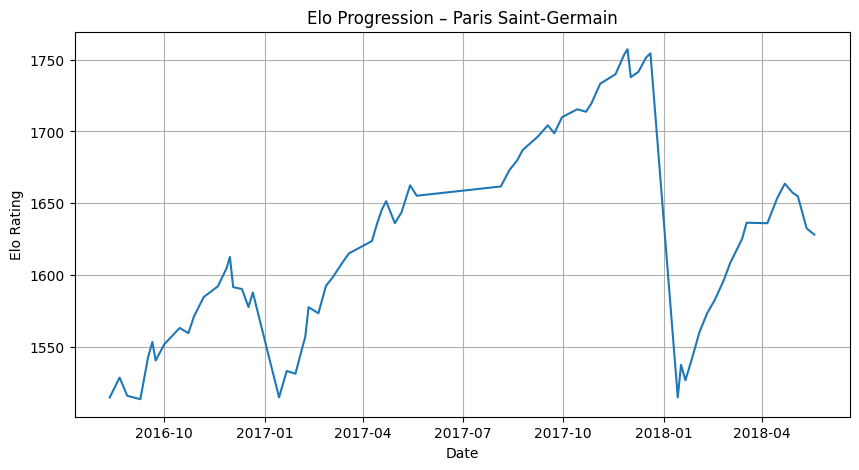

In [15]:
import matplotlib.pyplot as plt

team = "paris saint-germain"

team_df = elo_df[
    (elo_df["HomeTeam"] == team) | (elo_df["AwayTeam"] == team)
].copy()

team_df["elo"] = np.where(
    team_df["HomeTeam"] == team,
    team_df["home_elo_after"],
    team_df["away_elo_after"]
)

plt.figure(figsize=(10,5))
plt.plot(team_df["date"], team_df["elo"])
plt.title(f"Elo Progression – {team.title()}")
plt.xlabel("Date")
plt.ylabel("Elo Rating")
plt.grid(True)
plt.show()


### Generate win/draw/loss predictions from Elo differences

Elo differences can be converted into expected probabilities.
Comparing these probabilities with actual results shows how well the model performs.


In [16]:
def predict_from_elo(home_elo, away_elo):
    exp_home = expected_score(home_elo, away_elo)
    exp_away = 1 - exp_home

    if exp_home > 0.45 and exp_home < 0.55:
        pred = "D"  # draw zone
    elif exp_home >= 0.55:
        pred = "H"  # home win
    else:
        pred = "A"  # away win
    return pred

elo_df["pred"] = [
    predict_from_elo(hb, ab)
    for hb, ab in zip(elo_df["home_elo_before"], elo_df["away_elo_before"])
]

elo_df["actual"] = np.where(
    elo_df["FTHG"] > elo_df["FTAG"], "H",
    np.where(elo_df["FTHG"] < elo_df["FTAG"], "A", "D")
)


### Evaluate prediction accuracy

We compare predicted outcomes with real match results
to get a basic accuracy score for the Elo model.


In [17]:
accuracy = (elo_df["pred"] == elo_df["actual"]).mean()
accuracy


np.float64(0.42105263157894735)

### Quick sanity checks for accuracy

We compare our Elo-based accuracy with simple baselines:
- always predicting "home win"
- always predicting the most frequent outcome in the data

If Elo does not beat these baselines, we know the model needs improvement.


In [18]:
# Distribution of actual outcomes
actual_dist = elo_df["actual"].value_counts(normalize=True)

# Baseline 1: always predict "H"
baseline_home = (elo_df["actual"] == "H").mean()

# Baseline 2: always predict the most frequent outcome
most_common_outcome = elo_df["actual"].value_counts().idxmax()
baseline_most_common = (elo_df["actual"] == most_common_outcome).mean()

print("Model accuracy:", float(accuracy))
print("Baseline (always H):", float(baseline_home))
print("Baseline (always most common):", float(baseline_most_common))
print("\nActual outcome distribution:")
print(actual_dist)


Model accuracy: 0.42105263157894735
Baseline (always H): 0.4723684210526316
Baseline (always most common): 0.4723684210526316

Actual outcome distribution:
actual
H    0.472368
A    0.277632
D    0.250000
Name: proportion, dtype: float64


In [23]:
elo_df["date"].min(), elo_df["date"].max()


(Timestamp('2016-08-12 00:00:00'), Timestamp('2018-05-19 00:00:00'))

### Select a single Ligue 1 season for simulation

We focus on one season (e.g., 2018–2019).
This keeps the simulation realistic and easier to interpret.


In [25]:
# Define season boundaries (approximate Ligue 1 season)
season_start = "2016-08-01"
season_end   = "2017-06-30"

season_df = elo_df[
    (elo_df["date"] >= season_start) &
    (elo_df["date"] <= season_end)
].copy()

season_df.shape


(380, 12)

### Convert Elo ratings to win/draw/lose probabilities

We derive simple three-way probabilities from the Elo ratings:
- use the Elo formula for "home strength",
- keep a fixed base draw probability,
- assign the remaining mass to home and away wins.

This is a simplified but transparent approach for simulation.


In [26]:
DRAW_BASE = 0.25  # fixed base draw probability

def elo_to_probabilities(home_elo: float, away_elo: float):
    """
    Convert Elo ratings into (p_home, p_draw, p_away) in a simple, interpretable way.
    """
    exp_home = expected_score(home_elo, away_elo)

    # Adjust home win probability around the expected score, keeping a fixed draw base
    p_draw = DRAW_BASE
    p_home = exp_home - 0.5 * p_draw
    p_away = 1.0 - p_home - p_draw

    # Clamp to valid range [0, 1] to avoid numerical issues
    p_home = max(0.0, min(1.0, p_home))
    p_away = max(0.0, min(1.0, p_away))

    # Re-normalize if needed
    total = p_home + p_draw + p_away
    p_home /= total
    p_draw /= total
    p_away /= total

    return p_home, p_draw, p_away


### Run Monte Carlo simulations for the selected season

We simulate the same season many times (e.g., 500 runs).
For each run:
- sample match results from the Elo-based probabilities,
- award points (3 for win, 1 for draw),
- build a final league table.

By aggregating across runs, we estimate how often each team becomes champion.


In [28]:
import numpy as np
from collections import defaultdict

def simulate_season(season_matches: pd.DataFrame, n_sim: int = 500, random_seed: int = 42):
    np.random.seed(random_seed)

    champions = []

    teams = pd.unique(
        season_matches[["HomeTeam", "AwayTeam"]].values.ravel()
    )

    for sim in range(n_sim):
        points = defaultdict(int)

        for _, row in season_matches.iterrows():
            home = row["HomeTeam"]
            away = row["AwayTeam"]
            home_elo = row["home_elo_before"]
            away_elo = row["away_elo_before"]

            p_home, p_draw, p_away = elo_to_probabilities(home_elo, away_elo)

            r = np.random.rand()
            if r < p_home:
                points[home] += 3
            elif r < p_home + p_draw:
                points[home] += 1
                points[away] += 1
            else:
                points[away] += 3

        # Build table and pick champion
        table = (
            pd.DataFrame(
                {"team": list(points.keys()), "points": list(points.values())}
            )
            .sort_values(["points", "team"], ascending=[False, True])
            .reset_index(drop=True)
        )

        # Avoid KeyError if table is empty
        if not table.empty:
            champions.append(table.iloc[0]["team"])
        else:
            champions.append(None)  # or continue, or raise a custom warning


    return pd.Series(champions)

champions_series = simulate_season(season_df, n_sim=500)
champions_series.value_counts(normalize=True)



as monaco              0.342
paris saint-germain    0.276
nice                   0.130
bordeaux               0.054
st etienne             0.044
lyon                   0.028
stade rennes           0.020
marseille              0.018
angers                 0.016
guingamp               0.016
toulouse               0.010
nantes                 0.010
montpellier            0.008
metz                   0.008
caen                   0.006
bastia                 0.004
dijon fco              0.004
lille                  0.004
as nancy lorraine      0.002
Name: proportion, dtype: float64